# True Parameters at 1 PA Model

```python
m1 = 1e6
m2 = 10
a = 0.8 
e0 = 0.4 
xI0 = 1.0
dist = 0.4

qS = xp.pi/4
phiS = 1.0
qK = 1
phiK = xp.pi/3

Phi_phi0 = 0.9
Phi_theta0 = 0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p = 0.0
dev_0_e = 0.0
dev_1_p = 0.0
dev_1_e = 0.0
dev_2_p = 0.0
dev_2_e = 0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included = True

p0 = 7.5

best_fit = [13.81557873,10.00059572,0.80005484,7.49973356,0.39998203,0.78521213, 1.0002002,0.95198958,0.33550665]

In [5]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

In [6]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [7]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit = [13.81557873,10.00059572,0.80005484,7.49973356,0.39998203,0.78521213, 1.0002002,0.95198958,0.33550665]
#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 0.4
qS = best_fit[5]
phiS = best_fit[6]
qK = 1 
phiK = np.pi/3
Phi_phi0 = best_fit[7]
Phi_theta0 =0.5
Phi_r0 = best_fit[8]

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [8]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000068.1743594923), 10.00059572, 0.80005484, 7.49973356, 0.39998203, 1.0, 0.4, 0.78521213, 1.0002002, 1, 1.0471975511965976, 0.95198958, 0.5, 0.33550665, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  136.80746218528887


Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000068.1743594923), 10.00059572, 0.80005484, 7.49973356, 0.39998203, 1.0, 0.4, 0.78521213, 1.0002002, 1, 1.0471975511965976, 0.95198958, 0.5, 0.33550665, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.80746218528887
calculating stable deltas...
Gamma_ii for m1: 22245.99207104275
Gamma_ii for m1: 22245.9920643438
Gamma_ii for m1: 22245.99206426821
Gamma_ii for m1: 22245.992064403657
Gamma_ii for m1: 22245.992064996793
Gamma_ii for m1: 22245.99206418423
Gamma_ii for m1: 22245.992062505637
Gamma_ii for m1: 22245.992076156854
Gamma_ii for m1: 22245.992085069338
Gamma_ii for m1: 22245.992160370723
Gamma_ii for m1: 22245.992129758146
Gamma_ii for m1: 22245.991953544177
Gamma_ii for m1: 22245.991617125033
Gamma_ii for m1: 22245.992758405264
Gamma_ii for m1: 22245.99216153596
Gamma_ii for m1: 22245.986854078004
[np.float

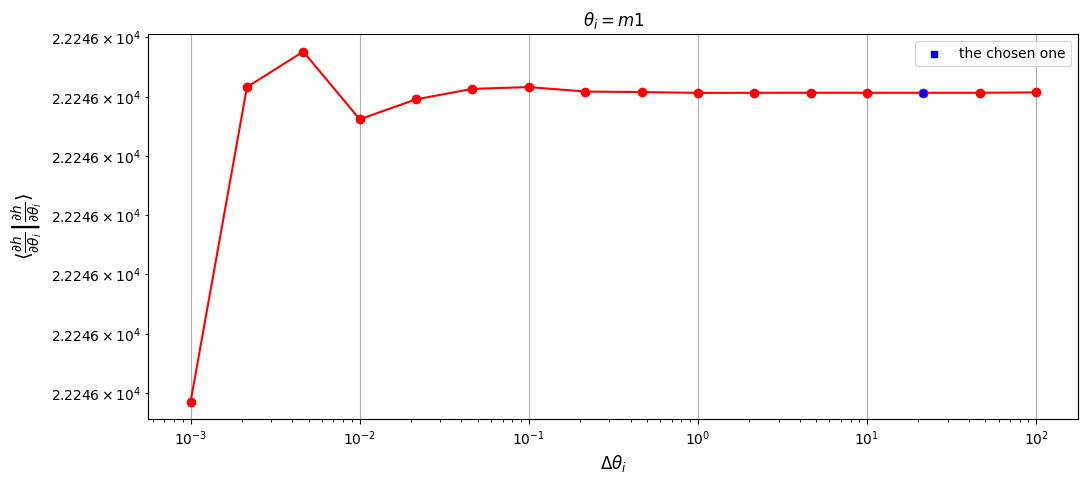

Gamma_ii for m2: 14184838771142.611
Gamma_ii for m2: 14184838770631.744
Gamma_ii for m2: 14184838770311.734
Gamma_ii for m2: 14184838770237.87
Gamma_ii for m2: 14184838771897.889
Gamma_ii for m2: 14184838768804.51
Gamma_ii for m2: 14184838773083.615
Gamma_ii for m2: 14184838806937.49
Gamma_ii for m2: 14184838711462.924
Gamma_ii for m2: 14184838657164.082
Gamma_ii for m2: 14184839321317.434
Gamma_ii for m2: 14184838060731.055
Gamma_ii for m2: 14184837950558.834
Gamma_ii for m2: 14184836226638.363
Gamma_ii for m2: 14184840840691.482
Gamma_ii for m2: 14184836724412.732
[np.float64(3.601501545140564e-11), np.float64(2.2559986109589546e-11), np.float64(5.207336901846318e-12), np.float64(1.1702773347968722e-10), np.float64(2.1807642347356115e-10), np.float64(3.016675435796845e-10), np.float64(2.3866238778436325e-09), np.float64(6.730747409140151e-09), np.float64(3.827949200497339e-09), np.float64(4.682135176282109e-08), np.float64(8.886857738587974e-08), np.float64(7.766900199151348e-09), np

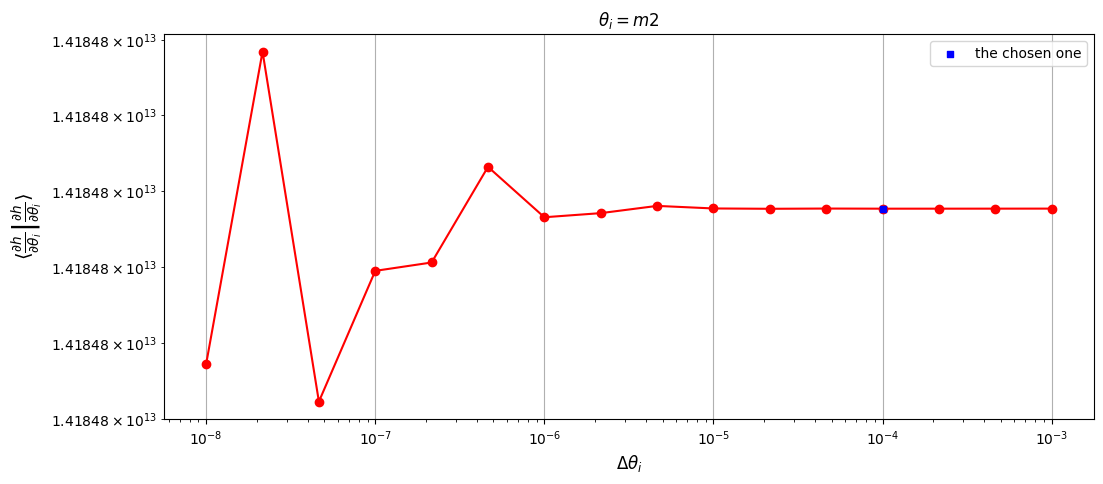

Gamma_ii for a: 1815316449708012.5
Gamma_ii for a: 1815316460787543.5
Gamma_ii for a: 1815316082205144.2
Gamma_ii for a: 1815316433479198.8
Gamma_ii for a: 1815315932453409.2
Gamma_ii for a: 1815317209464437.5
Gamma_ii for a: 1815318543363655.0
Gamma_ii for a: 1815315468709989.0
Gamma_ii for a: 1815315473758954.0
Gamma_ii for a: 1815270142660856.0
Gamma_ii for a: 1815080028730840.0
Gamma_ii for a: 1815003063898546.2
Gamma_ii for a: 1814321055191634.2
Gamma_ii for a: 1814175672635993.0
Gamma_ii for a: 1816607412186845.8
Gamma_ii for a: 1815544162335962.5
[np.float64(6.103360620215683e-09), np.float64(2.0854902513182128e-07), np.float64(1.935056875052661e-07), np.float64(2.759992244561314e-07), np.float64(7.034643981735562e-07), np.float64(7.348017362442519e-07), np.float64(1.6937296679264954e-06), np.float64(2.7813154644383452e-09), np.float64(2.4972094804331907e-05), np.float64(0.00010474134859438321), np.float64(4.2404794694083294e-05), np.float64(0.00037590298859204065), np.float64(8

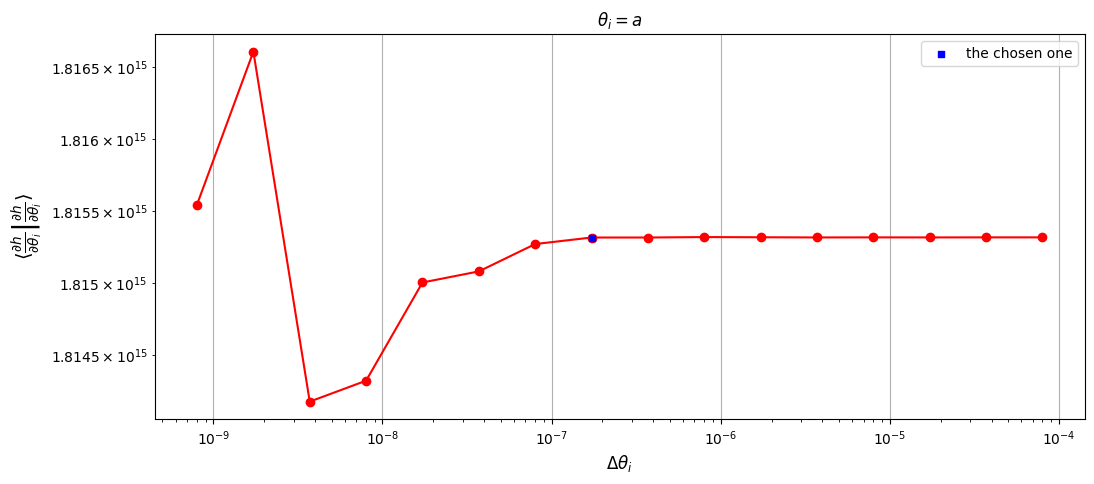

Gamma_ii for p0: 1172795959517934.8
Gamma_ii for p0: 1172795968953836.0
Gamma_ii for p0: 1172795943829200.8
Gamma_ii for p0: 1172795938137075.2
Gamma_ii for p0: 1172795879643582.5
Gamma_ii for p0: 1172796141786525.2
Gamma_ii for p0: 1172795240259259.5
Gamma_ii for p0: 1172794880949502.0
Gamma_ii for p0: 1172797825594282.8
Gamma_ii for p0: 1172797475264441.8
Gamma_ii for p0: 1172798181956266.5
Gamma_ii for p0: 1172808701011414.5
Gamma_ii for p0: 1172749369137848.0
Gamma_ii for p0: 1172783073291424.0
Gamma_ii for p0: 1173075832822069.0
Gamma_ii for p0: 1173384835744746.5
[np.float64(8.045646045677548e-09), np.float64(2.1422853124787927e-08), np.float64(4.853466246687077e-09), np.float64(4.987525430919523e-08), np.float64(2.2351961556650123e-07), np.float64(7.686996287184004e-07), np.float64(3.063705029212786e-07), np.float64(2.5107863576212577e-06), np.float64(2.987129904257407e-07), np.float64(6.02568997481915e-07), np.float64(8.969114177724387e-06), np.float64(5.0592117231423536e-05), 

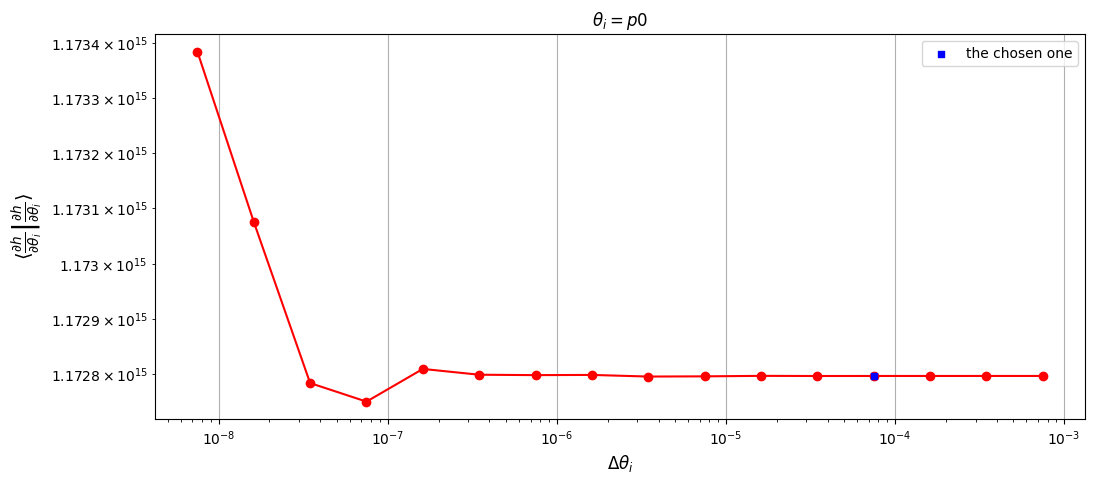

Gamma_ii for e0: 3817219786823447.5
Gamma_ii for e0: 3817219984892863.0
Gamma_ii for e0: 3817219634180438.5
Gamma_ii for e0: 3817217982331594.5
Gamma_ii for e0: 3817219171173098.5
Gamma_ii for e0: 3817224895790952.0
Gamma_ii for e0: 3817229853355958.5
Gamma_ii for e0: 3817214256496105.0
Gamma_ii for e0: 3817211456899807.0
Gamma_ii for e0: 3816878268248247.5
Gamma_ii for e0: 3816951626099874.0
Gamma_ii for e0: 3816911603905494.5
Gamma_ii for e0: 3817625938795536.5
Gamma_ii for e0: 3817484501820169.5
Gamma_ii for e0: 3819446066053972.0
Gamma_ii for e0: 3819274764462759.5
[np.float64(5.1888394246044265e-08), np.float64(9.187640694279787e-08), np.float64(4.3273631520278924e-07), np.float64(3.114417723189439e-07), np.float64(1.49968052964661e-06), np.float64(1.298733688290084e-06), np.float64(4.085927277191053e-06), np.float64(7.334139933326421e-07), np.float64(8.729349697401185e-05), np.float64(1.9218962882549387e-05), np.float64(1.0485491552528743e-05), np.float64(0.00018711495088682604),

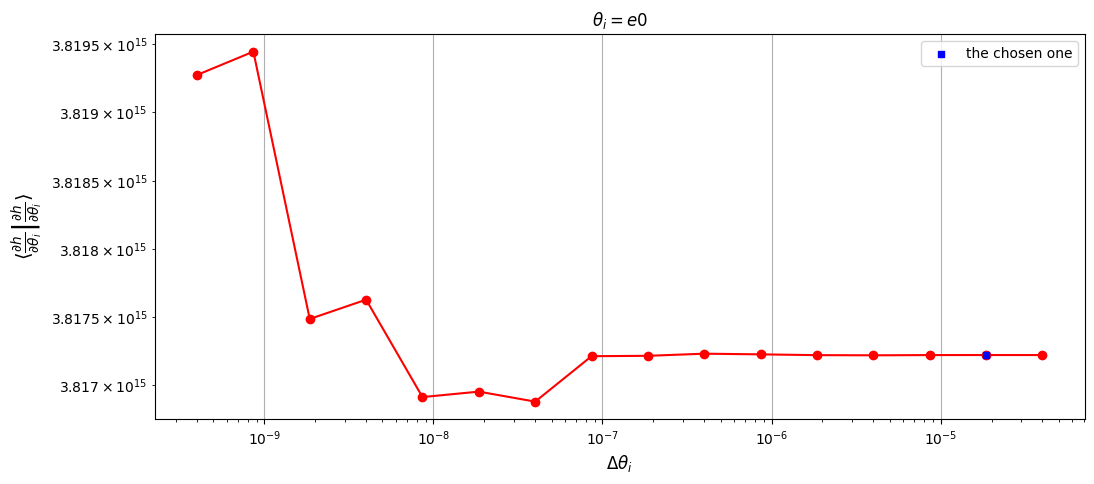

Gamma_ii for qS: 56879.62342702332
Gamma_ii for qS: 56879.623522960654
Gamma_ii for qS: 56879.62352317157
Gamma_ii for qS: 56879.623523172086
Gamma_ii for qS: 56879.62352317181
Gamma_ii for qS: 56879.62352317034
Gamma_ii for qS: 56879.62352316805
Gamma_ii for qS: 56879.62352318342
Gamma_ii for qS: 56879.62352319703
Gamma_ii for qS: 56879.623523193826
Gamma_ii for qS: 56879.623523196686
Gamma_ii for qS: 56879.62352342146
Gamma_ii for qS: 56879.623522750226
Gamma_ii for qS: 56879.62352285802
Gamma_ii for qS: 56879.623521376765
Gamma_ii for qS: 56879.623524568335
[np.float64(1.6866731815470619e-09), np.float64(3.708102238651889e-12), np.float64(9.082215363056498e-15), np.float64(4.860903997128853e-15), np.float64(2.583954230052773e-14), np.float64(4.029433576567605e-14), np.float64(2.7029184594555707e-13), np.float64(2.392076440691296e-13), np.float64(5.628415154568072e-14), np.float64(5.027198081238957e-14), np.float64(3.951787031122172e-12), np.float64(1.180099571985392e-11), np.float64

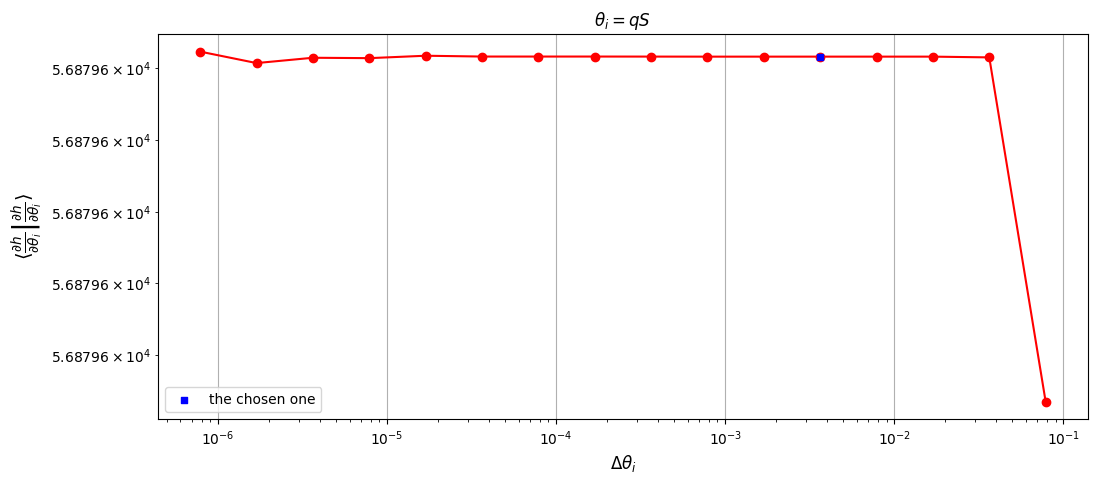

Gamma_ii for phiS: 1107806.8233514277
Gamma_ii for phiS: 1107806.8233148071
Gamma_ii for phiS: 1107806.8233147261
Gamma_ii for phiS: 1107806.823314726
Gamma_ii for phiS: 1107806.823314726
Gamma_ii for phiS: 1107806.823314726
Gamma_ii for phiS: 1107806.823314726
Gamma_ii for phiS: 1107806.823314726
Gamma_ii for phiS: 1107806.8233147254
Gamma_ii for phiS: 1107806.8233147264
Gamma_ii for phiS: 1107806.823314727
Gamma_ii for phiS: 1107806.8233147298
Gamma_ii for phiS: 1107806.8233147294
Gamma_ii for phiS: 1107806.8233147461
Gamma_ii for phiS: 1107806.8233147298
Gamma_ii for phiS: 1107806.8233146705
[np.float64(3.3056787686934763e-11), np.float64(7.314006583666577e-14), np.float64(2.1017260297892467e-16), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(4.203452059578495e-16), np.float64(8.406904119156983e-16), np.float64(6.305178089367733e-16), np.float64(2.522071235747087e-15), np.float64(4.20345205957848e-16), np.float64(1.51324274144823e-14), np.float64(1.4

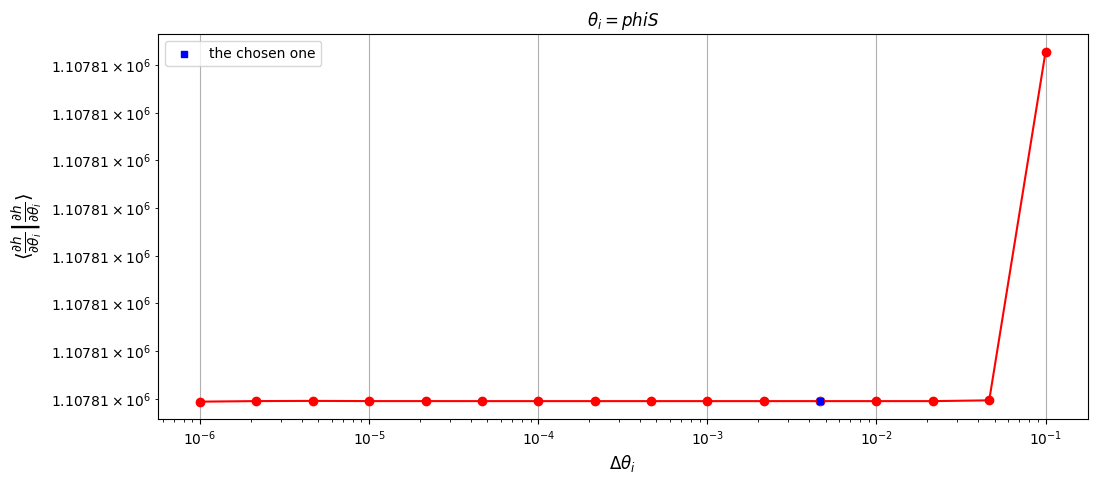

stable deltas: {'m1': 21.545815672369454, 'm2': 0.00010000595720000005, 'a': 1.7236659012239099e-07, 'p0': 7.499733559999998e-05, 'e0': 1.856552124093772e-05, 'qS': 0.003644631854625306, 'phiS': 0.004642518079697267, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 221.68525099754333 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 14.981204748153687 seconds


In [9]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [10]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(1e6), 10, 0.8, 7.5, 0.4, np.pi/4, 1.0,  0.9,0.4])

In [11]:
pd.DataFrame(fisher_)

,0,1,2,3,4,5,6,7,8
0,2.224903e+16,-5.493299e+14,5.989204e+15,5.098848e+15,8.883479e+15,-2.881912e+10,1.333716e+11,-3.497239e+10,-1.305313e+10
1,-5.493299e+14,1.418484e+13,-1.580546e+14,-1.273419e+14,-2.065221e+14,6.464001e+08,-2.990586e+09,7.841320e+08,2.311795e+08
2,5.989204e+15,-1.580546e+14,1.815315e+15,1.401988e+15,2.189345e+15,-7.021586e+09,3.248834e+10,-8.518229e+09,-1.690807e+09
3,5.098848e+15,-1.273419e+14,1.401988e+15,1.172796e+15,2.006914e+15,-6.500673e+09,3.008349e+10,-7.888313e+09,-2.718188e+09
4,8.883479e+15,-2.065221e+14,2.189345e+15,2.006914e+15,3.817220e+15,-1.299624e+10,6.016539e+10,-1.577756e+10,-7.195365e+09
5,-2.881912e+10,6.464001e+08,-7.021586e+09,-6.500673e+09,-1.299624e+10,5.687962e+04,-2.384542e+05,6.253995e+04,2.888238e+04
6,1.333716e+11,-2.990586e+09,3.248834e+10,3.008349e+10,6.016539e+10,-2.384542e+05,1.107807e+06,-2.896858e+05,-1.337662e+05
7,-3.497239e+10,7.841320e+08,-8.518229e+09,-7.888313e+09,-1.577756e+10,6.253995e+04,-2.896858e+05,7.598316e+04,3.507783e+04
8,-1.305313e+10,2.311795e+08,-1.690807e+09,-2.718188e+09,-7.195365e+09,2.888238e+04,-1.337662e+05,3.507783e+04,3.662272e+04


In [12]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):

    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                ax.axis("off")
                continue
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D - 1 and j == 0:
                    # ellipse handles (match levels dynamically)
                    level_labels = {f"{int(p*100)}%" for p in levels}
                    for item in ax.get_lines():
                        if item.get_label() in level_labels:
                            legend_handles.append(item)
                
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


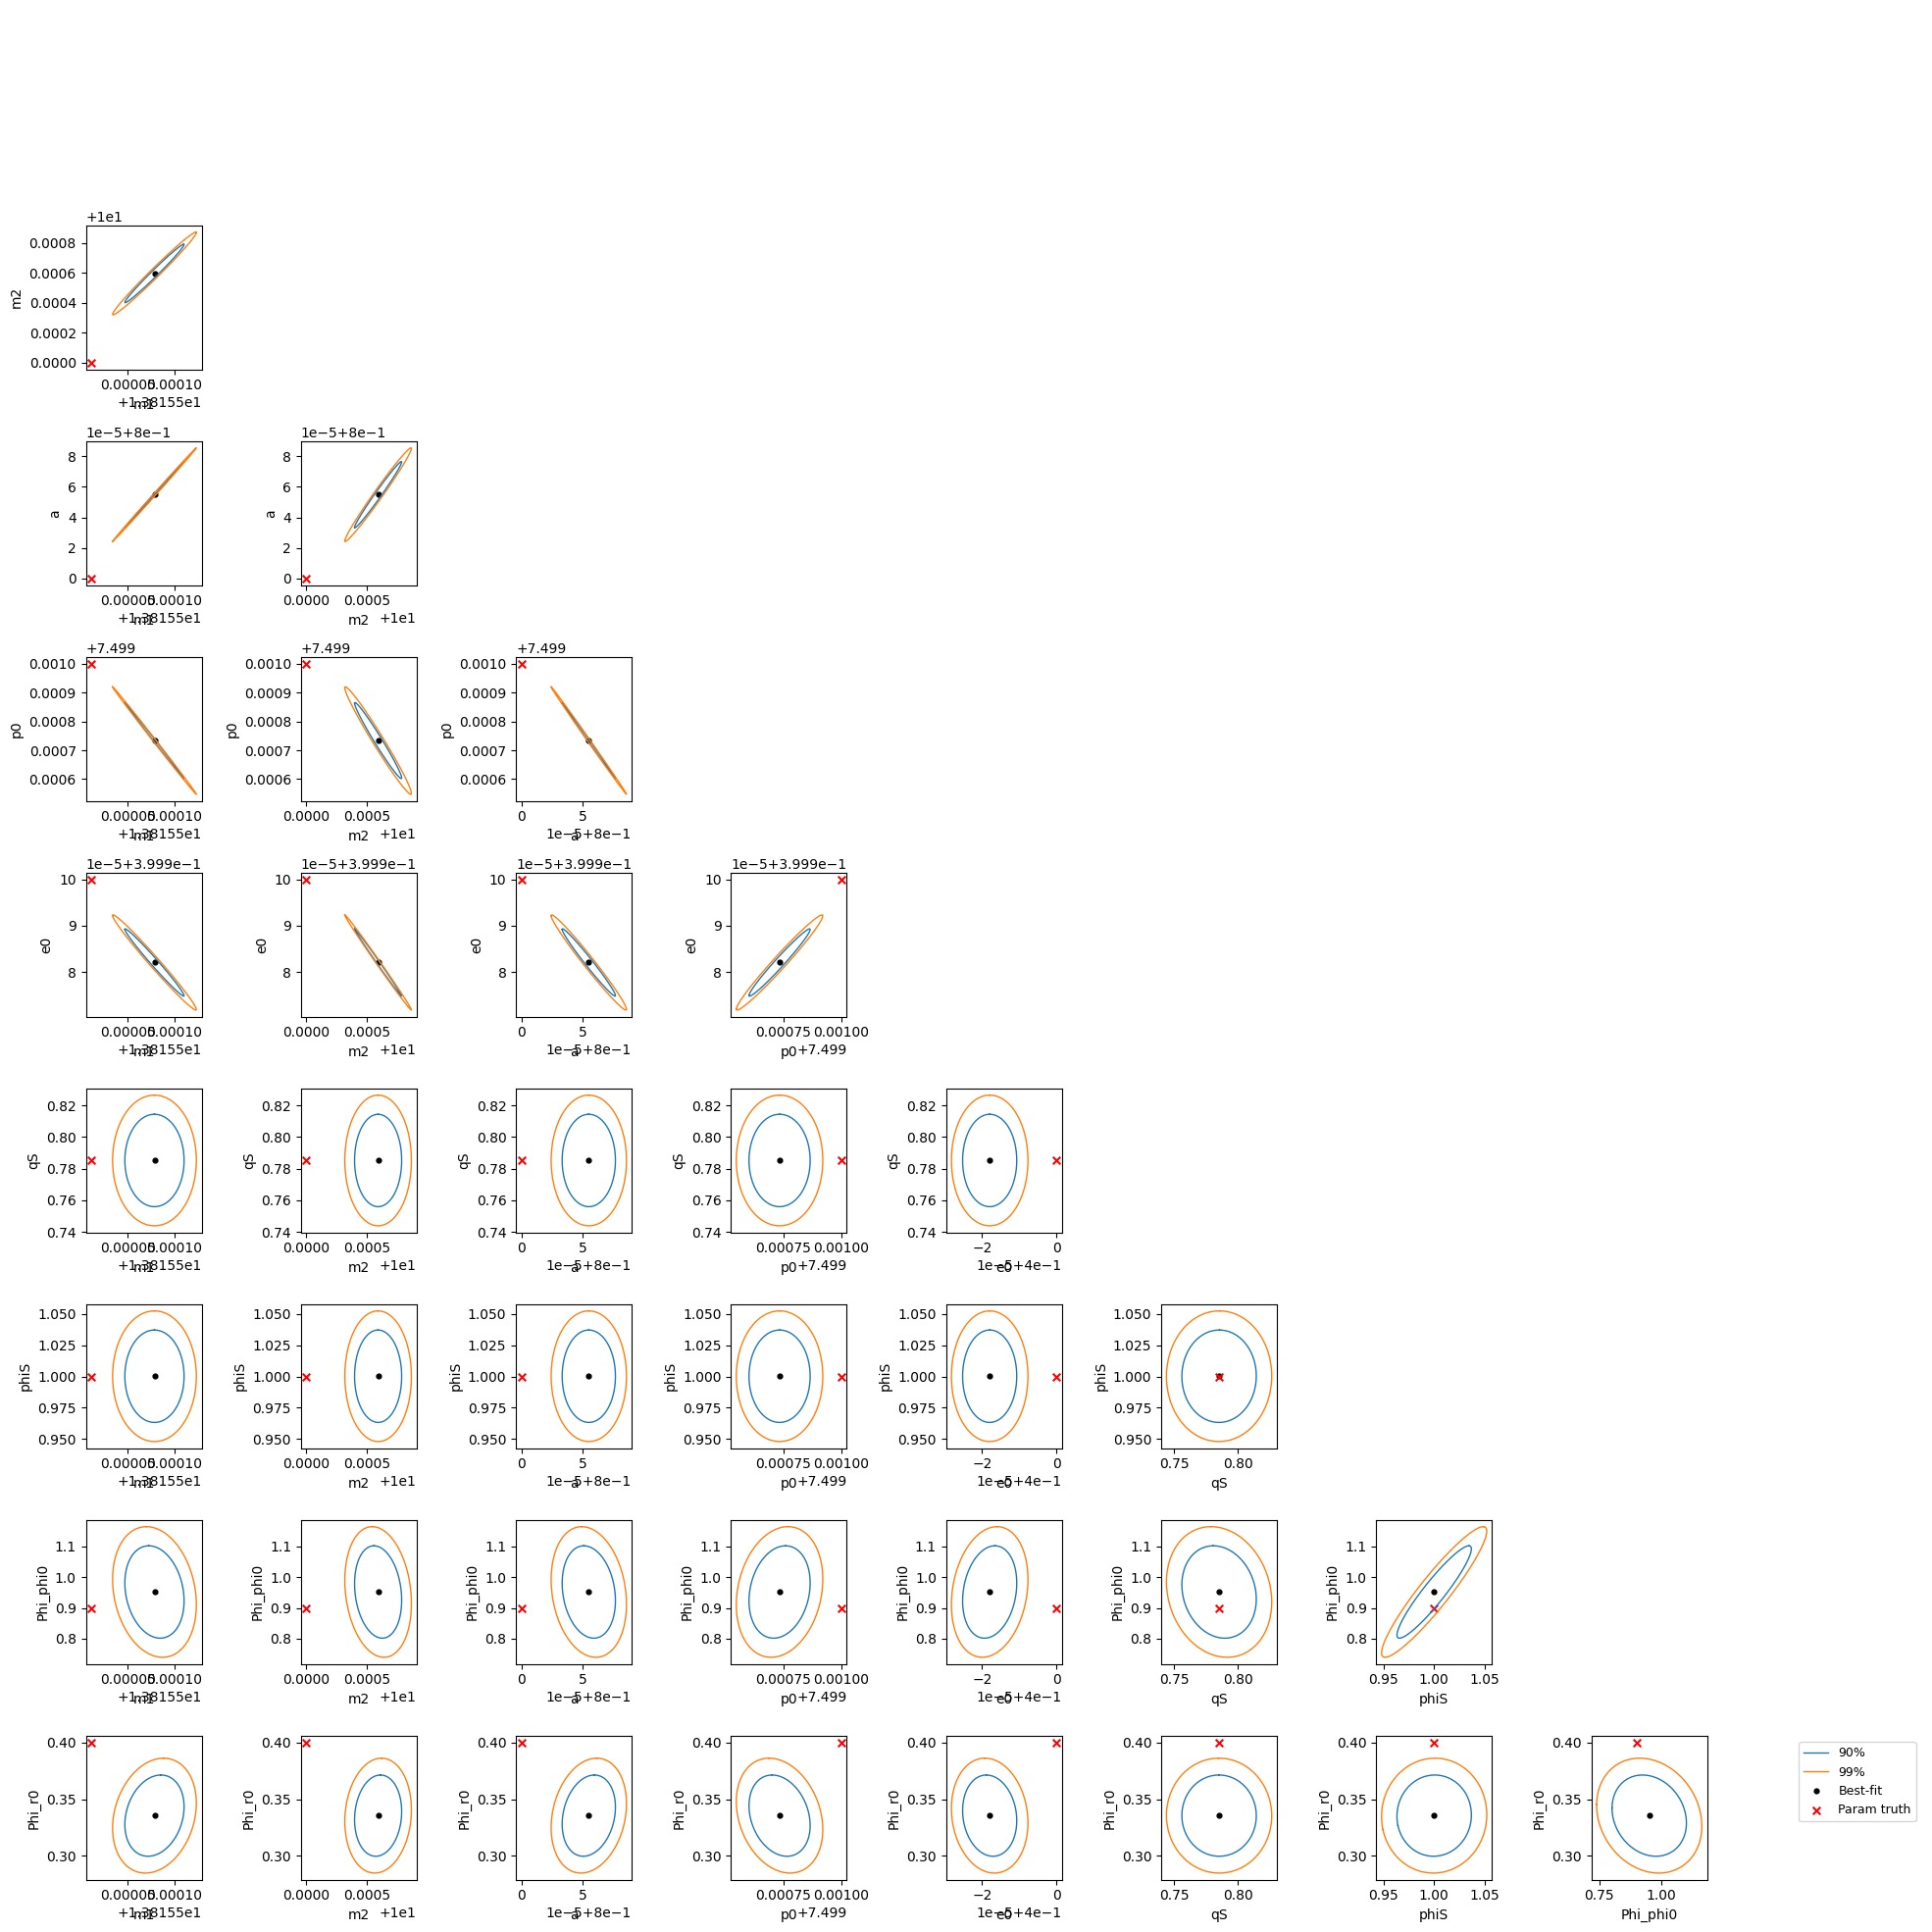

In [13]:
labels = param_names
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.90, 0.99])


In [14]:
# True waveform with 1PA order
m1_true = 1e6
m2_true = 10
a_true = 0.8 
e0_true = 0.4 # 0.6 just spin first
xI0_true = 1.0
dist_true = 0.4
qS_true = xp.pi/4
phiS_true = 1.0
qK_true = 1 
phiK_true = xp.pi/3
Phi_phi0_true = 0.9
Phi_theta0_true =0.5
Phi_r0_true = 0.4
p0_true=7.5
chi2 = 0.0
dev_0_p_true=0.0
dev_0_e_true=0.0

evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,0,0,0,0]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])


In [15]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [16]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)

# waveform analysis and p0 evolution 

In [17]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=0.5, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should+0.1)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  6.439843289124535
separatrix p:  3.3636344376256564


# P evolution is done considering true waveform (1PA)


[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


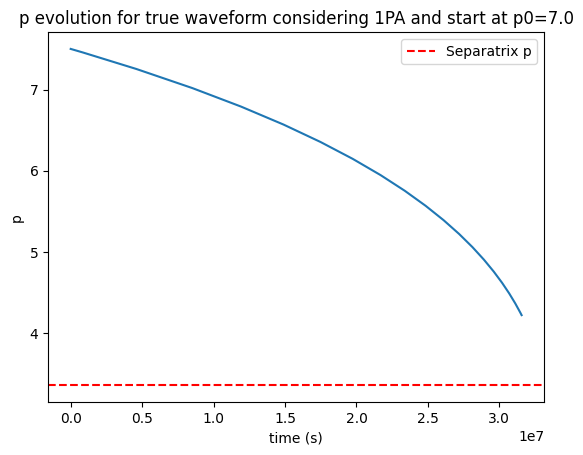

In [18]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.0')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

# Waveform Visualization

# Overlap and mismatch

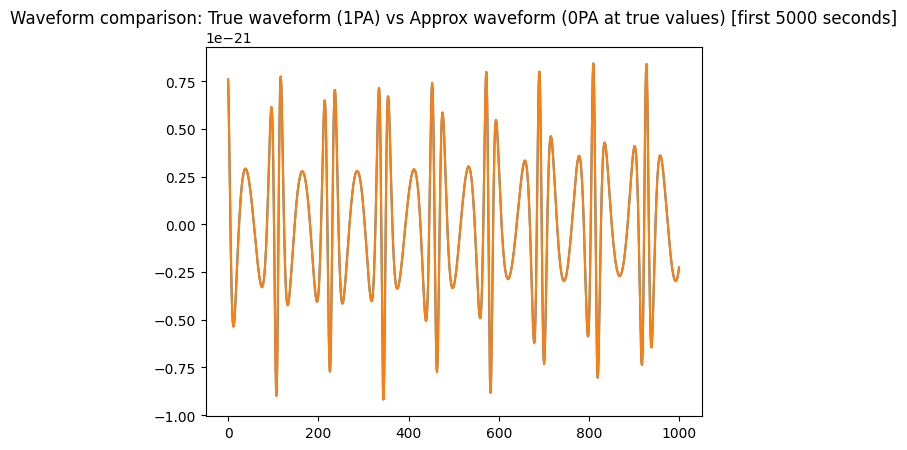

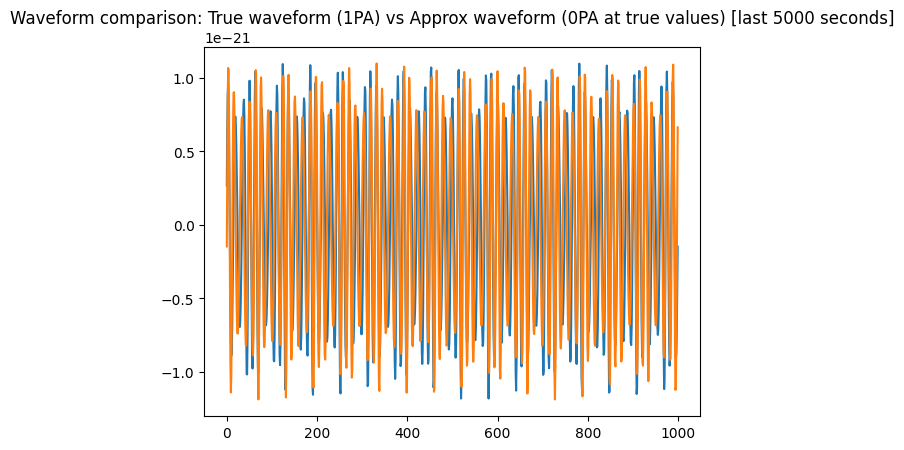

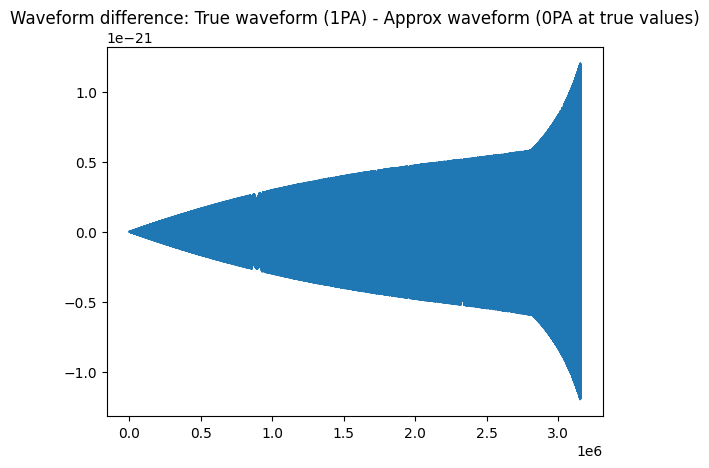

In [19]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

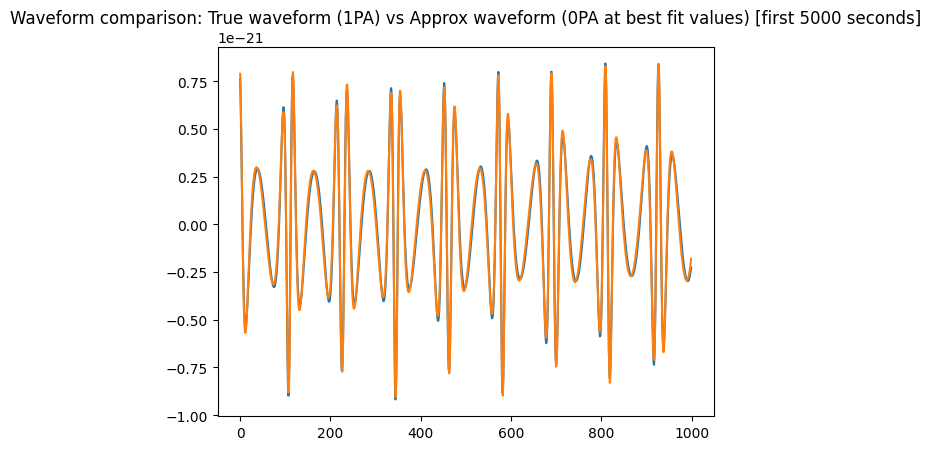

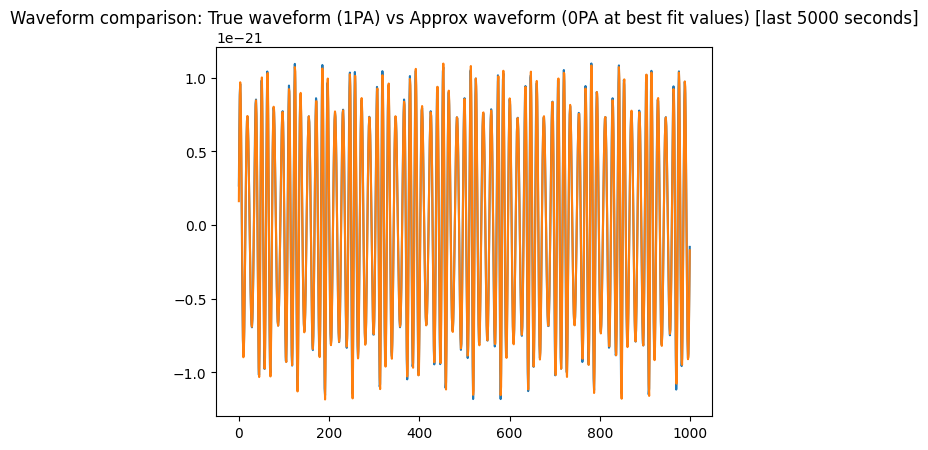

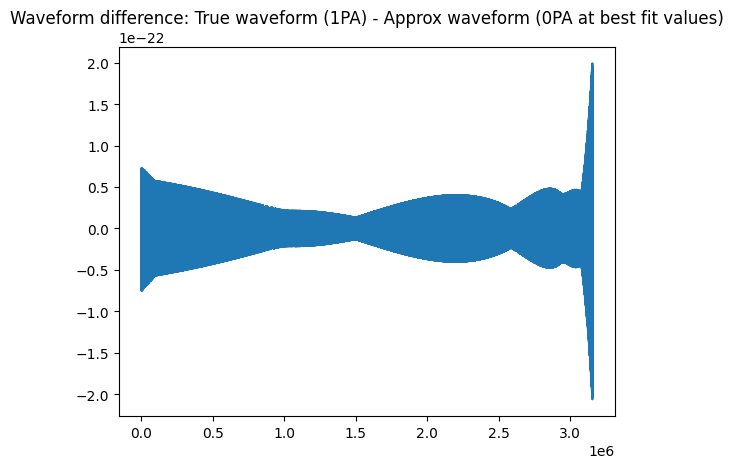

In [20]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

In [21]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.9993645967965302
mismatch between best fit point and true waveform: 0.0006354032034697754
overlap between approximate waveform and true waveform (both at true points) 0.9005241196983437
mismatch between approximate waveform and true waveform (both at true points): 0.09947588030165633


# Table true vs bias

In [22]:
best_fit

[13.81557873,
 10.00059572,
 0.80005484,
 7.49973356,
 0.39998203,
 0.78521213,
 1.0002002,
 0.95198958,
 0.33550665]

In [23]:

import pandas as pd
best_fit[0] = np.exp(13.81561299)
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true]
df = pd.DataFrame({'Best Fit': best_fit, 'True Param': truue_param}, index=param_names)
print(df)

              Best Fit      True Param
m1        1.000102e+06  1000000.000000
m2        1.000060e+01       10.000000
a         8.000548e-01        0.800000
p0        7.499734e+00        7.500000
e0        3.999820e-01        0.400000
qS        7.852121e-01        0.785398
phiS      1.000200e+00        1.000000
Phi_phi0  9.519896e-01        0.900000
Phi_r0    3.355067e-01        0.400000


In [24]:
# #Orthoganal check between derivative and exact fisher matrices
# PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
#                 noise_PSD=get_sensitivity,
#                 noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
#                 channels=["A","E"])
# inner_val = []
# for i in range(fisher_derivs.shape[0]):
#     temp_deriv = inner_product(fisher_derivs[i],waveform_true-sef.waveform, PSD=PSD, dt=dt,use_gpu=use_gpu)
#     inner_val.append(temp_deriv)
